# PyTorch Workflow

In [ ]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (training)",
                      4: "making predictions and evaluating the model",
                      5: "saving and loading a model",
                      6: "putting it all together"}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating the model',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [ ]:
import torch
from torch import nn ##Neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.8.0+cu126'

## 1. Data - Preparing and loading

Data can be almost anything... in ML
* Excel spreadsheet
* Images of any kind
* Videos
* Audio like songs or podcasts
* DNA
* Text

Machine Learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation

To showcase this, let's create some *known* data using the linear regression formula.

We'll use a linear regression formula to make a straight line with known parameters.

In [ ]:
# Create *known* parameters

weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim = 1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets (Important)

Let's create a training and test set with our data

In [ ]:
# Create a train test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

This is where the data explorer's motto comes in!

"Visualize, visualize, visualize!"

In [ ]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
  """
  Plots training data, test data and comapres predictions
  """
  plt.figure(figsize = (10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c = "b", s = 4, label = "Training data")

   # Plot test data in green
  plt.scatter(test_data, test_labels, c = "y", s = 4, label = "Test data")

  # Are there predictions?
  if predictions is not None:
    # Plot the predictions if they exist
    plt.scatter(test_data, predictions, c = "r", s = 4, label = "Predictions")

  # Show the legend
  plt.legend(prop = {"size" : 14});

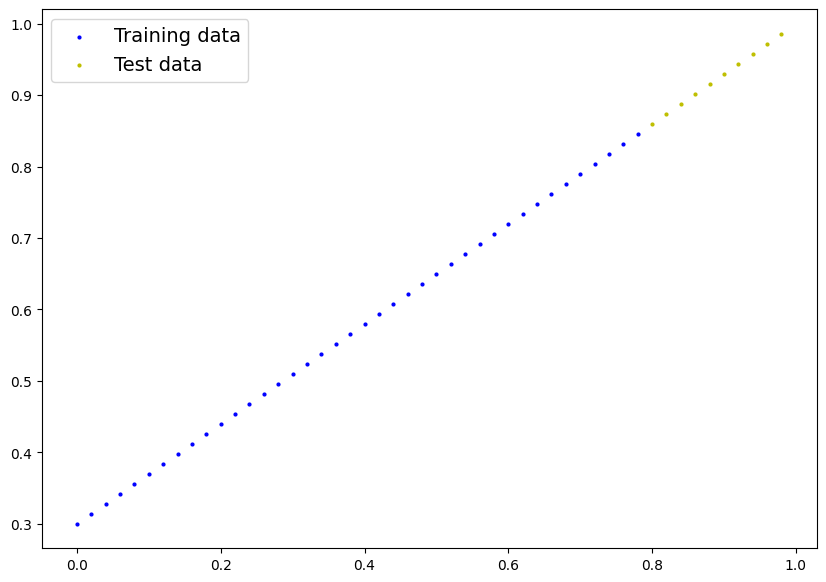

In [ ]:
plot_predictions();

###2. Build model

What the model does:
* Start with random values (weights & bias)

* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weights and bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient Descent
2. Backpropagation

In [ ]:
from torch import nn

# Create a linear regression model class
class LinearRegressionModel(nn.Module): # <- Almost everything in PyTorch inherits from nn.Module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad = True,
                                            dtype = torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad = True,
                                         dtype = torch.float))

  # Forward method to define the computation in the model
  def forward(self, X: torch.Tensor) -> torch.Tensor: # <- "x" is the input(training data).
    return self.weights * X + self.bias #Linear regression

## PyTorch model building essentials

* torch.nn - contains all of the building blocks for computational graphs (an NN can be considered a computational graph)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network modules,
if you subclass it, you should write forward()
* torch.optim - this is where the optimizers in PyTorch live, they will help with Gradient Descent
* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation
https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html

### Checking the contents of our PyTorch model

Now we've created a model, let's see what's inside...

So we can check our model parameters or what's inside our model using *'.parameters()'*

In [ ]:
# Create a random seed (to avoid getting different values every time)
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check of the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# Known ideal values
weight, bias

(0.7, 0.3)

### Making prediction using 'torch.inference_mode()'

To check our model's predictive power, let's see how well it predicts 'y_test' based on 'X_test'

Data passed will run through 'forward()' method

In [ ]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [ ]:
#Alternative
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [ ]:
# Make predictions with model (no grad function in output)
# Inference mode turns off gradient tracking (faster predictions)
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

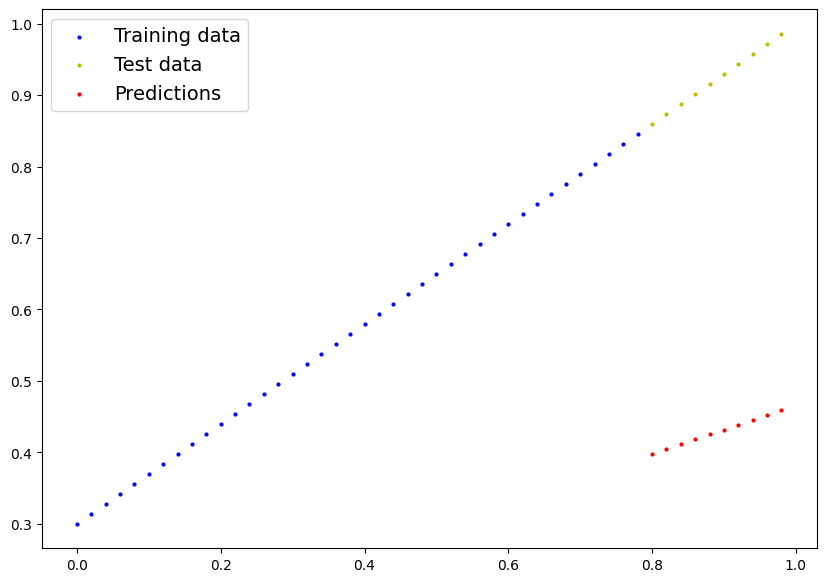

In [ ]:
plot_predictions(predictions = y_preds)

## 3. Train model

The whole idea of training is for a model to move from random to 'known' parameters.

From a poor to a better representation of the data.

One way to measure how wrong our model's predictions are is to a loss function

* Note: Loss function may also be called cost function or criterion in different areas.

Things we need in order to train:

* **Loss Function:** A function to measure how wrong your model's predictions are to the ideal outputs, the lower the better.

* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias) to improve the loss function.
https://docs.pytorch.org/docs/stable/optim.html

And specifically for PyTorch, we need:
* A training loop
* A testing loop

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# Check out model's parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer (stochastic = random)
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.01) #learning rate

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:
0. Loop through the data
1. Forward pass (this involves data moving through model's 'forward()' functions) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss.(**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss. (**gradient descent**)

In [ ]:
# An epoch is one loop through the data...(hyperparameter as we set it ourselves)
epochs = 200

# For tracking model progress
epoch_count = []
loss_values = []
test_loss_values = []

### Training
# 0. Loop through the data
for epoch in range(epochs):
  #print(f"epoch : {epoch + 1}")
  # Set the model to training mode (default mode btw)
  model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)
  #print(f"Loss: {loss}")

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Perform backprop on the loss w.r.t. the parameters of the model
  loss.backward()

  # 5. Step the optimizer (perform gradient descent)
  optimizer.step() #by default how the optimizer changes will accumulate through the loop so... we have to zero them above in step 3 for the next iteration of the loop

  ### Testing
  model_0.eval() #turns off different settings in the model not needed for evaulation/testing (dropout/batch norm)

  # Turns off gradient tracking and a couple of more settings
  with torch.inference_mode():
    # 1. Forward pass
    test_preds = model_0(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_preds, y_test)

  if epoch%10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)

    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
    #Print out model state_dict()
    print(f"{model_0.state_dict()}\n")

Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})

Epoch: 10 | Loss: 0.1976713240146637 | Test Loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})

Epoch: 20 | Loss: 0.08908725529909134 | Test Loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})

Epoch: 30 | Loss: 0.053148526698350906 | Test Loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})

Epoch: 40 | Loss: 0.04543796554207802 | Test Loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})

Epoch: 50 | Loss: 0.04167863354086876 | Test Loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})

Epoch: 60 | Loss: 0.03818932920694351 | Test Loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})

Epoch: 70 | Los

In [ ]:
import numpy as np
np.array(torch.tensor(loss_values).detach().numpy()), test_loss_values

/tmp/ipython-input-3644362518.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  np.array(torch.tensor(loss_values).detach().numpy()), test_loss_values


(array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
        0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
        0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
        0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
       dtype=float32),
 [tensor(0.4811),
  tensor(0.3464),
  tensor(0.2173),
  tensor(0.1446),
  tensor(0.1136),
  tensor(0.0992),
  tensor(0.0889),
  tensor(0.0806),
  tensor(0.0723),
  tensor(0.0647),
  tensor(0.0565),
  tensor(0.0482),
  tensor(0.0406),
  tensor(0.0323),
  tensor(0.0241),
  tensor(0.0165),
  tensor(0.0082),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050)])

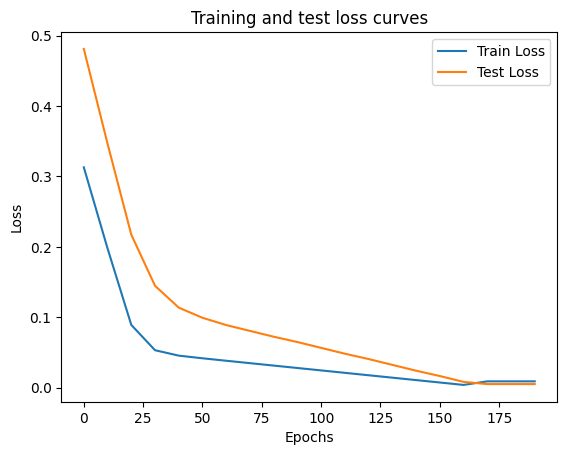

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).detach().numpy()), label = "Train Loss")
plt.plot(epoch_count, test_loss_values, label = "Test Loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

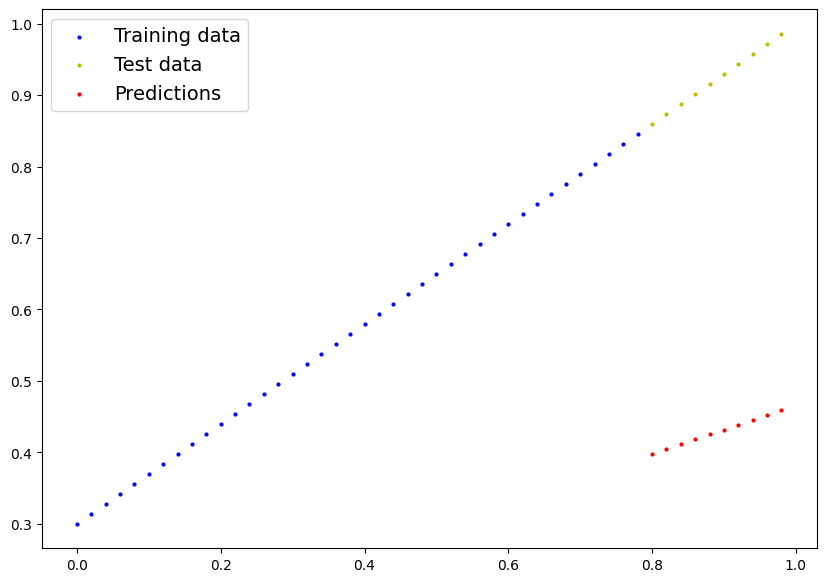

In [ ]:
plot_predictions(predictions = y_preds);

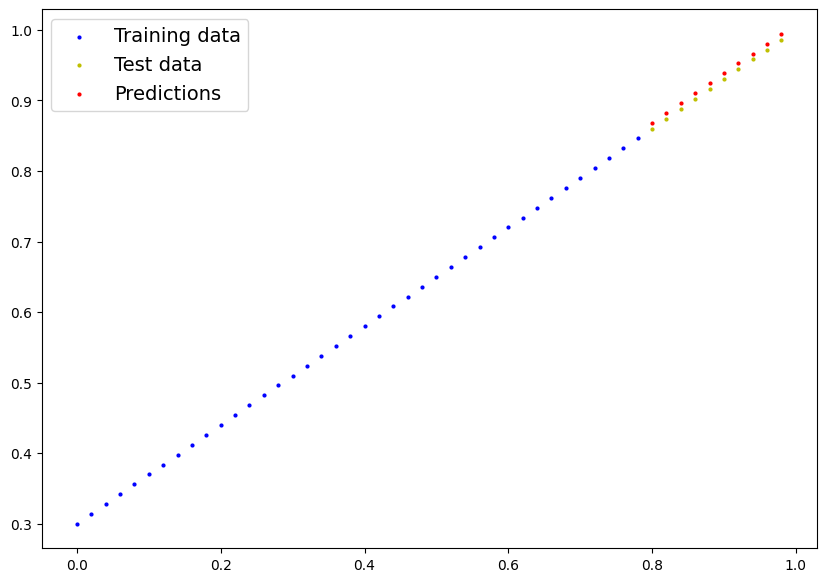

In [ ]:
plot_predictions(predictions = y_preds_new);

## Saving a model in PyTorch

There are three main methods for saving and loading models in PyTorch:

1. torch.save() - Allows you to save a PyTorch object in pickle format.

2. torch.load() - Allows you to load a saved PyTorch object.

3. torch.nn.Module.load_state_dict() - Allows you ot load a model's saved state dictionary

https://docs.pytorch.org/tutorials/beginner/basics/saveloadrun_tutorial.html

In [ ]:
# Saving our PyTorch model
from pathlib import Path

#1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# 2. Craete model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
print(f"Saving model to: {MODEL_SAVE_PATH}")

# 3. Save the model state dict
torch.save(obj = model_0.state_dict(),
           f = MODEL_SAVE_PATH)


Saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Oct 19 05:11 01_pytorch_workflow_model_0.pth


## Loading a PyTorch model

Since we saved our model's 'state_dict()' rather the entire model, we'll create a new instance of our model class and load the saved 'state_dict()' into that.

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Make some predictions with our loaded model
loaded_model_0.eval()

with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [ ]:
# Compare loaded model preds with originals model preds
y_preds_new == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Putting it all together

Let's go back through the steps above and all in one place

In [ ]:
# Import pytorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.8.0+cu126'

Create deviced agnostic code
This means if we've got access to a GPU, our code will use it(faster computing)
else the code will default to using CPU.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device : {device}")

Using device : cuda


### 6.1 Data

In [ ]:
# Create some data using the linear regression formula y = w*x + b
weight = 0.6
bias = 0.4
# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) #ithout unsqueeze errors pop up
y = weight*X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.4000],
         [0.4120],
         [0.4240],
         [0.4360],
         [0.4480],
         [0.4600],
         [0.4720],
         [0.4840],
         [0.4960],
         [0.5080]]))

In [ ]:
# Split data
train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]

X_test = X[train_split:]
y_test = y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

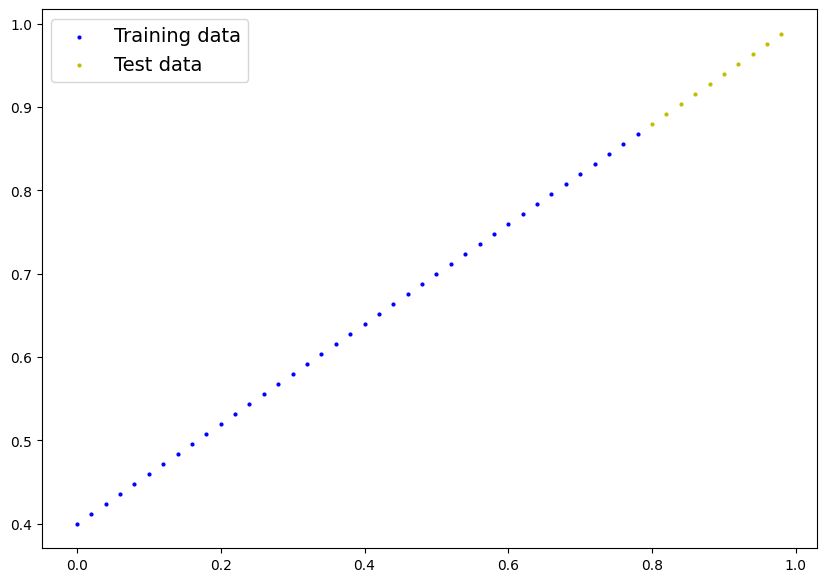

In [ ]:
# Plot the data
# Note : plot_predictions() function must be loaded
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
  """
  Plots training data, test data and comapres predictions
  """
  plt.figure(figsize = (10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c = "b", s = 4, label = "Training data")

   # Plot test data in green
  plt.scatter(test_data, test_labels, c = "y", s = 4, label = "Test data")

  # Are there predictions?
  if predictions is not None:
    # Plot the predictions if they exist
    plt.scatter(test_data, predictions, c = "r", s = 4, label = "Predictions")

  # Show the legend
  plt.legend(prop = {"size" : 14});

plot_predictions(X_train, y_train, X_test, y_test)

In [ ]:
## 6.2 Building a PyTorch linear model
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()

    # Use nn.Linear for creating model parameters # also called (linear transform, dense, probation) layer
    self.linear_layer = nn.Linear(in_features = 1,   #1 output for each (1) input
                                  out_features = 1)

  def forward(self, X: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(X)

# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()


(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
X_train[:5], y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.4000],
         [0.4120],
         [0.4240],
         [0.4360],
         [0.4480]]))

In [ ]:
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
# Set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.8300], device='cuda:0'))])

### 6.3 Training

For training we need:
* Loss Function
* Optimizer
* Training Loop
* Testing Loop

In [ ]:
# Setup loss function
loss_fn = nn.L1Loss() # MAE

# Setup our optimizer
optimizer = torch.optim.Adam(params = model_1.parameters(), lr = 0.01)

In [ ]:
# Let's write a training loop
torch.manual_seed(42)

epochs = 250

# Put data on the target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  # 1. Forward pass
  y_pred = model_1(X_train)

  # 2. loss
  loss = loss_fn(y_pred, y_train)

  # 3. optimizer zero_grad
  optimizer.zero_grad()

  # 4. Backprop
  loss.backward()

  # 5. optimizer step
  optimizer.step()

  # Testing
  model_1.eval()
  with torch.inference_mode():
    y_test_preds = model_1(X_test)
    test_loss = loss_fn(y_test_preds, y_test)

    if epoch % 10 == 0:
      print(f"epoch : {epoch} | Loss : {loss} | Test_Loss = {test_loss}")


epoch : 0 | Loss : 0.494177907705307 | Test_Loss = 0.5575472116470337
epoch : 10 | Loss : 0.3551780581474304 | Test_Loss = 0.3685474097728729
epoch : 20 | Loss : 0.21617817878723145 | Test_Loss = 0.17954757809638977
epoch : 30 | Loss : 0.07717832177877426 | Test_Loss = 0.010326123796403408
epoch : 40 | Loss : 0.04721915349364281 | Test_Loss = 0.1394377201795578
epoch : 50 | Loss : 0.041240204125642776 | Test_Loss = 0.10984501987695694
epoch : 60 | Loss : 0.026154661551117897 | Test_Loss = 0.03475780412554741
epoch : 70 | Loss : 0.01765989139676094 | Test_Loss = 0.035667575895786285
epoch : 80 | Loss : 0.009614321403205395 | Test_Loss = 0.02120721898972988
epoch : 90 | Loss : 0.0018640622729435563 | Test_Loss = 0.0013659120304509997
epoch : 100 | Loss : 0.0018354908097535372 | Test_Loss = 0.004277026746422052
epoch : 110 | Loss : 0.0006905697518959641 | Test_Loss = 0.00048021675320342183
epoch : 120 | Loss : 0.0005806371918879449 | Test_Loss = 0.0020425200928002596
epoch : 130 | Loss : 

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6034]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.4006], device='cuda:0'))])

In [ ]:
weight, bias

(0.6, 0.4)

### 6.4 Making and evaluating predictions


In [ ]:
model_1.eval()
with torch.inference_mode():
  y_test_preds = model_1(X_test)
y_test_preds

tensor([[0.8833],
        [0.8954],
        [0.9075],
        [0.9196],
        [0.9316],
        [0.9437],
        [0.9558],
        [0.9678],
        [0.9799],
        [0.9920]], device='cuda:0')

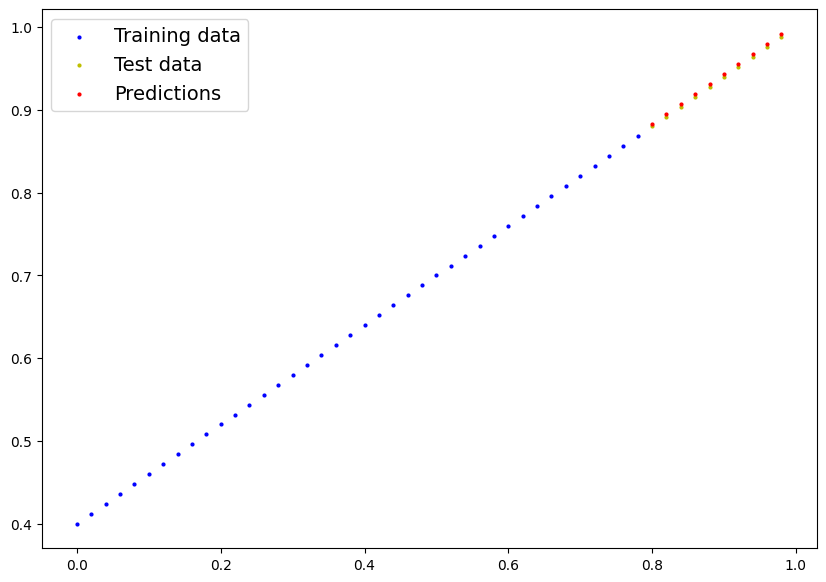

In [ ]:
# Check out predictions visually

plot_predictions(predictions = y_test_preds.cpu())

### 6.5 Saving and loading a trained model

In [ ]:
from pathlib import Path

Model_path = Path("models")
Model_path.mkdir(parents = True, exist_ok = True)

Model_Name = "01_pytorch_workflow_model_1.pth"
Model_Save_path = Model_path / Model_Name

print(f"Saving model to : {Model_Save_path}")

torch.save(obj = model_1.state_dict(),
           f = Model_Save_path)

Saving model to : models/01_pytorch_workflow_model_1.pth


In [ ]:
loaded_model_1 = LinearRegressionModelV2()

loaded_model_1.load_state_dict(torch.load(f = Model_Save_path))
loaded_model_1 = loaded_model_1.to(device)
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6034]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.4006], device='cuda:0'))])

In [ ]:
loaded_model_1.eval()
with torch.inference_mode():
  y_loaded_preds = loaded_model_1(X_test)
y_loaded_preds == y_test_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

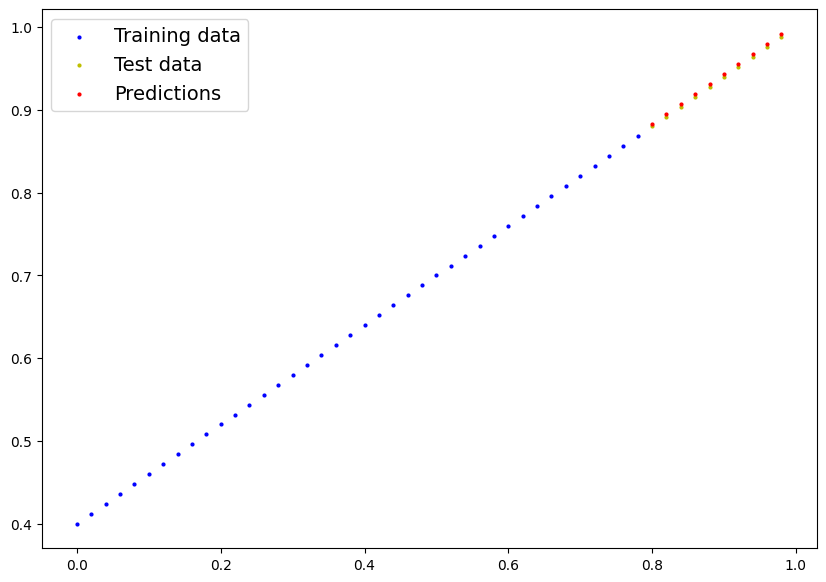

In [ ]:
plot_predictions(predictions = y_loaded_preds.cpu())

## Exercises

In [ ]:
weight = 0.3
bias = 0.9

X = torch.arange(0,1,0.01).unsqueeze(dim = 1)
Y = weight*X + bias

len(X), len(Y)

(100, 100)

In [ ]:
split = int(0.8 * len(X))

X_train, Y_train = X[:split], Y[:split]
X_test, Y_test = X[split:], Y[split:]

len(X_train), len(Y_train), len(X_test), len(Y_test)

(80, 80, 20, 20)

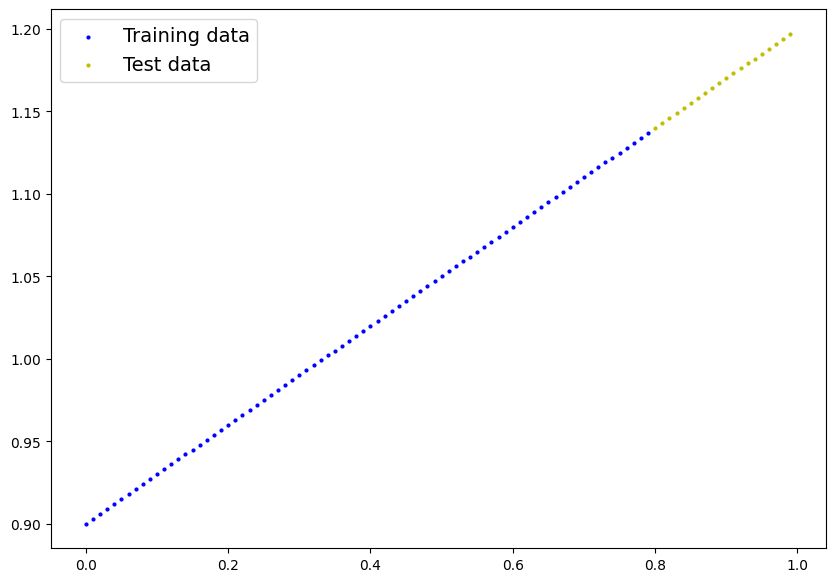

In [ ]:
plot_predictions(X_train, Y_train, X_test, Y_test)

In [ ]:
class LinearRegressionModelV3(nn.Module):
  def __init__(self):
    super().__init__()

    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad = True,
                                            dtype = torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                            requires_grad = True,
                                            dtype = torch.float))
    # self.linear_layer = nn.Linear(in_features = 1, out_features = 1)

  def forward(self, X: torch.Tensor) -> torch.Tensor:
    return self.weights * X + self.bias
    # return self.linear_layer(X)

In [ ]:
torch.manual_seed(42)

model2 = LinearRegressionModelV3()
list(model2.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model2.parameters(), lr = 0.01)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device : {device}")

Using device : cuda


In [ ]:
epochs = 300
torch.manual_seed(42)

for epoch in range(epochs):
  model2.train()

  # 1. Forward pass
  y_pred = model2(X_train)

  # 2. loss
  loss = loss_fn(y_pred, Y_train)

  # 3. optimizer zero_grad
  optimizer.zero_grad()

  # 4. Backprop
  loss.backward()

  # 5. optimizer step
  optimizer.step()

  # Testing
  model2.eval()
  with torch.inference_mode():
    y_test_preds = model2(X_test)
    test_loss = loss_fn(y_test_preds, Y_test)

    if epoch % 10 == 0:
      print(f"epoch : {epoch} | Loss : {loss} | Test_Loss = {test_loss}")


epoch : 0 | Loss : 0.7566978335380554 | Test_Loss = 0.7248174548149109
epoch : 10 | Loss : 0.6410952806472778 | Test_Loss = 0.5894648432731628
epoch : 20 | Loss : 0.5254928469657898 | Test_Loss = 0.4541124403476715
epoch : 30 | Loss : 0.40989047288894653 | Test_Loss = 0.31876006722450256
epoch : 40 | Loss : 0.2942880392074585 | Test_Loss = 0.18340764939785004
epoch : 50 | Loss : 0.17868563532829285 | Test_Loss = 0.04805523157119751
epoch : 60 | Loss : 0.07658576965332031 | Test_Loss = 0.07274086028337479
epoch : 70 | Loss : 0.05743539333343506 | Test_Loss = 0.11017072200775146
epoch : 80 | Loss : 0.05255373567342758 | Test_Loss = 0.11581540107727051
epoch : 90 | Loss : 0.04897591844201088 | Test_Loss = 0.11232650279998779
epoch : 100 | Loss : 0.045542728155851364 | Test_Loss = 0.10467890650033951
epoch : 110 | Loss : 0.0421157106757164 | Test_Loss = 0.09703131765127182
epoch : 120 | Loss : 0.03868866711854935 | Test_Loss = 0.08938358724117279
epoch : 130 | Loss : 0.0352616049349308 | T

In [ ]:
model2.state_dict()

OrderedDict([('weights', tensor([0.3067])), ('bias', tensor([0.9011]))])

In [ ]:
model2.eval()
with torch.inference_mode():
  y_test_preds = model2(X_test)
len(y_test_preds), len(X_test)

(20, 20)

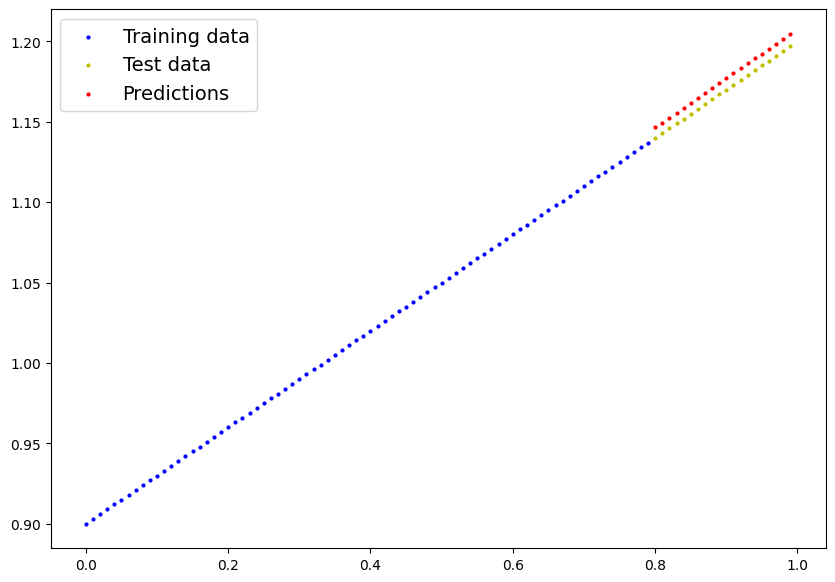

In [ ]:
plot_predictions(X_train, Y_train, X_test, Y_test, predictions = y_test_preds.cpu())

In [ ]:
from pathlib import Path

Model_path = Path("models")
Model_path.mkdir(parents = True, exist_ok = True)

Model_Name = "01_pytorch_workflow_model2.pth"
Model_Save_path = Model_path / Model_Name

print(f"Saving model to : {Model_Save_path}")

torch.save(obj = model2.state_dict(),
           f = Model_Save_path)

Saving model to : models/01_pytorch_workflow_model2.pth


In [ ]:
loaded_model2 = LinearRegressionModelV3()

loaded_model2.load_state_dict(torch.load(f = Model_Save_path))
loaded_model2 = loaded_model2.to(device)
loaded_model2.state_dict()

OrderedDict([('weights', tensor([0.3067], device='cuda:0')),
             ('bias', tensor([0.9011], device='cuda:0'))])

In [ ]:
loaded_model2.eval()
loaded_model2.to("cpu")
with torch.inference_mode():
  y_loaded_preds = loaded_model2(X_test)
y_loaded_preds == y_test_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

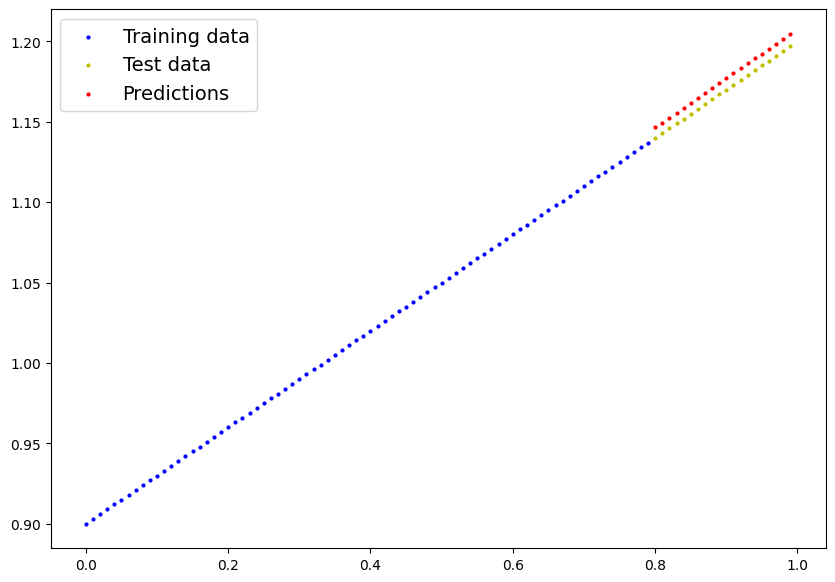

In [ ]:
plot_predictions(X_train,Y_train,X_test, Y_test, predictions= y_loaded_preds.cpu())

### The End